In [8]:
import pandas as pd
import numpy as np
import os

from sklearn.metrics import (
    roc_auc_score, precision_score, 
    recall_score, f1_score, 
    matthews_corrcoef,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)
from utils import *

import mlflow
import mlflow.sklearn

import warnings
import argparse
import logging
from typing import *

import matplotlib.pyplot as plt
import seaborn as sns

from namespaces import DA

In [2]:
logging.basicConfig(level=logging.WARN)
logger = logging.getLogger(__name__)
warnings.filterwarnings("ignore")

In [3]:
os.chdir('/home/mai/notebooks/final_thesis/')
os.getcwd()

'/home/mai/notebooks/final_thesis'

In [4]:
# search for the best run
experiment_name = 'svm_calibrated_grid_search'
metric_name = ['ap']

exp = mlflow.get_experiment_by_name(experiment_name)
runs = mlflow.search_runs(
    experiment_ids=[exp.experiment_id],
    order_by=[
        f"metrics.{metric_name[0]} DESC",
        # f"metrics.{metric_name[1]} DESC"
    ],
    max_results=1
)

best_run = runs.iloc[0]
best_run_id = best_run.run_id

print("Experiment ID:", exp.experiment_id)
print("Best run:", best_run_id)
print("Best metric - AP:", best_run[f"metrics.{metric_name[0]}"])

Experiment ID: 10
Best run: 725d09d554ef4a2f878cab059d0b1c58
Best metric - AP: 0.07943330800886868


In [5]:
# load best model
model = mlflow.sklearn.load_model(f"runs:/{best_run.run_id}/model")

In [6]:
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",LinearSVC(C=1...om_state=1111)
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the nu

In [9]:
def load_data(data_path):
    data = np.load(os.path.join(data_path, 'dgraphfin_processed.npz'))
    # train
    X_train = pd.DataFrame(data['x_train'])
    y_train = pd.DataFrame(data['y_train'])
    # val
    X_val = pd.DataFrame(data['x_val'])
    y_val = pd.DataFrame(data['y_val'])
    # test
    X_test = pd.DataFrame(data['x_test'])
    y_test = pd.DataFrame(data['y_test'])
    return X_train, X_val, X_test, y_train, y_val, y_test


def eval_metrics(actual, pred_labels, pred_probas):
    auc = roc_auc_score(actual, pred_probas)
    ap = average_precision_score(actual, pred_probas)
    recall = recall_score(actual, pred_labels)
    precision = precision_score(actual, pred_labels)
    f1 = recall_score(actual, pred_labels)
    matthews_corr = matthews_corrcoef(actual, pred_labels)
    rc_at_125 = recall_at_top_n_percent(actual, pred_probas, n_percent=1.25)
    pr_at_125 = precision_at_top_n_percent(actual, pred_probas, n_percent=1.25)
    return auc, ap, recall, precision, f1, matthews_corr, rc_at_125, pr_at_125

In [10]:
_, X_val, X_test, _, y_val, y_test = load_data(DA.paths.output_data_ml)

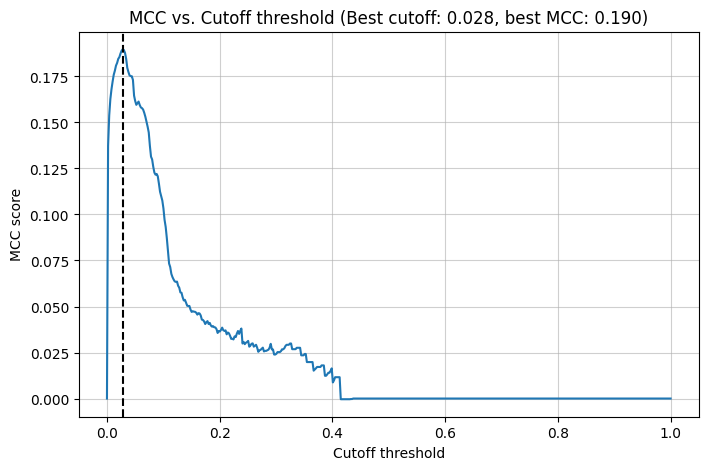

In [11]:
# cutoff selection to maximize mcc
y_prob = model.predict_proba(X_val)[:, 1]
thresholds = np.linspace(0, 1, 500)
mcc_scores = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    mcc_scores.append(matthews_corrcoef(y_val, y_pred))

best_idx = np.argmax(mcc_scores)
best_threshold = thresholds[best_idx]
best_mcc = mcc_scores[best_idx]

plt.figure(figsize=(8, 5))
plt.plot(thresholds, mcc_scores)
plt.axvline(best_threshold, ls='--', color='k')
plt.title(f"MCC vs. Cutoff threshold (Best cutoff: {best_threshold:.3f}, best MCC: {best_mcc:.3f})")
plt.xlabel("Cutoff threshold")
plt.ylabel("MCC score")
plt.grid(True, axis='both', alpha=.6)
plt.show()

In [15]:
# use selected threshold on test set
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= best_threshold).astype(int)

# eval
auc, ap, recall, precision, f1, mcc, rc_at_125, pr_at_125 = eval_metrics(y_test, y_pred, y_prob)

In [16]:
print(f'AUC: {auc:.4f}')
print(f'AP: {ap:.4f}')
print(f'Recall: {recall:.4f}')
print(f'Precision: {precision:.4f}')
print(f'F1: {f1:.4f}')
print(f'MCC: {mcc:.4f}')
print(f'Recall at top 1.25%: {rc_at_125:.4f}')
print(f'Precision at top 1.25%: {pr_at_125:.4f}')

AUC: 0.9011
AP: 0.0732
Recall: 0.8766
Precision: 0.0535
F1: 0.8766
MCC: 0.1868
Recall at top 1.25%: 0.0649
Precision at top 1.25%: 0.0657


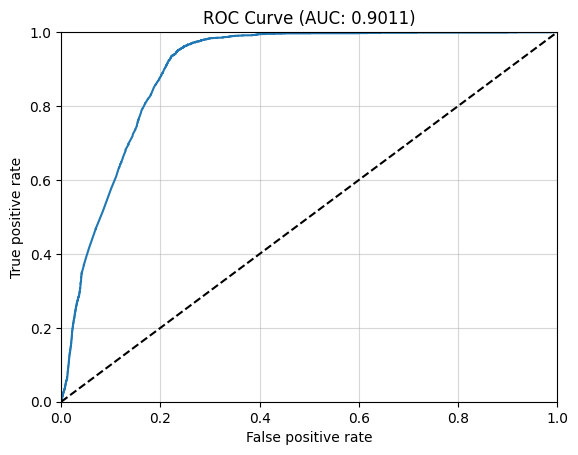

In [17]:
# examine ROC curve
fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], ls='--', color='k')
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title(f"ROC Curve (AUC: {auc:.4f})")
plt.grid(True, axis='both', alpha=0.5)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

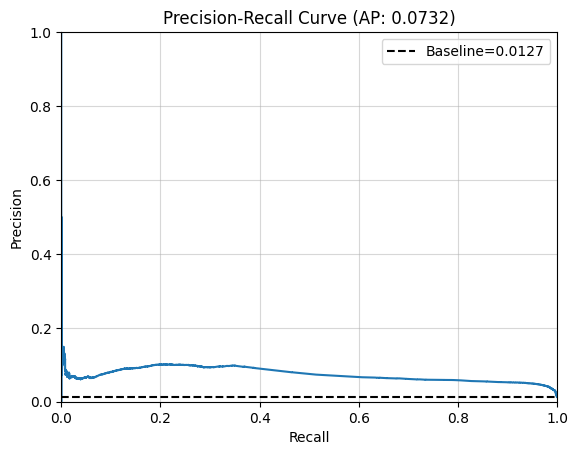

In [18]:
# examine precision recall curve
pr, rc, thresholds = precision_recall_curve(y_test, y_prob)
ap_value = average_precision_score(y_test, y_prob)
baseline = np.mean(y_test)

plt.figure()
plt.plot(rc, pr)
plt.axhline(baseline, linestyle="--", label=f"Baseline={baseline:.4f}", color='k')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AP: {ap_value:.4f})")
plt.grid(True, axis='both', alpha=0.5)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.show()

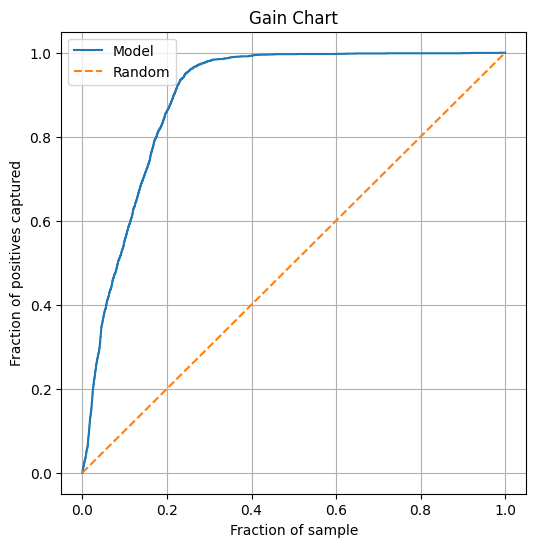

In [19]:
# examine gain and lift charts
gl = pd.DataFrame({
    'y_test': y_test.values.ravel(),
    'y_prob': y_prob
})

gl = gl.sort_values(by='y_prob', ascending=False).reset_index(drop=True)

gl['cum_positives'] = gl['y_test'].cumsum()
gl['gain'] = gl['cum_positives'] / gl['y_test'].sum()
gl['samples_frac'] = np.arange(1, len(gl)+1) / len(gl)

plt.figure(figsize=(6, 6))
plt.plot(gl["samples_frac"], gl["gain"], label="Model")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")  # random baseline
plt.xlabel("Fraction of sample")
plt.ylabel("Fraction of positives captured")
plt.title("Gain Chart")
plt.legend()
plt.grid(True)
plt.show()

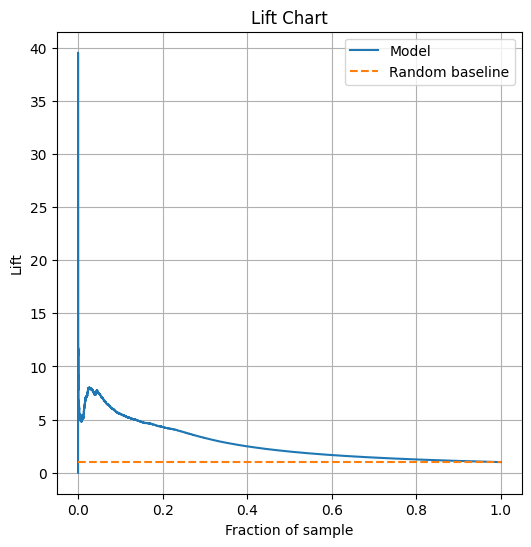

In [20]:
# examine lift chart
gl['lift'] = gl['gain'] / gl['samples_frac']

plt.figure(figsize=(6, 6))
plt.plot(gl["samples_frac"], gl["lift"], label="Model")
plt.plot([0, 1], [1, 1], linestyle="--", label="Random baseline")  # baseline lift = 1
plt.xlabel("Fraction of sample")
plt.ylabel("Lift")
plt.title("Lift Chart")
plt.legend()
plt.grid(True)
plt.show()

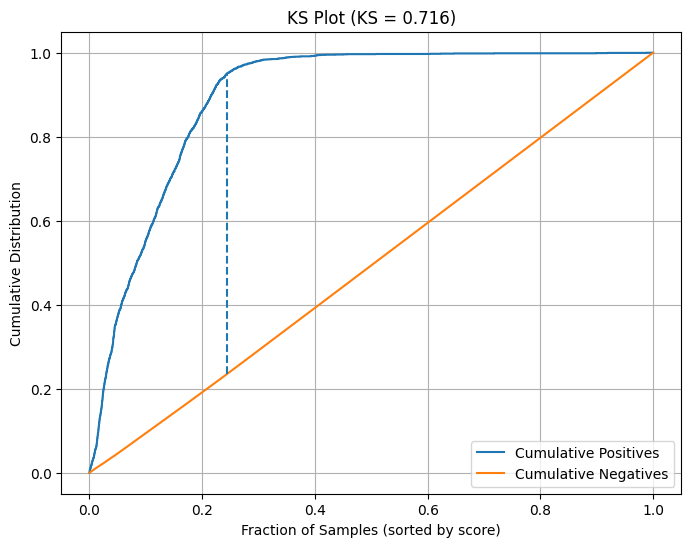

In [21]:
# KS plot
# negatives indicator
gl['neg'] = 1 - gl['y_test']

# cumulative negatives
gl['cum_negatives'] = gl['neg'].cumsum()

# normalize both cumulative curves
gl['cum_pos_rate'] = gl['cum_positives'] / gl['cum_positives'].iloc[-1]
gl['cum_neg_rate'] = gl['cum_negatives'] / gl['cum_negatives'].iloc[-1]

# KS distance
gl['ks'] = gl['cum_pos_rate'] - gl['cum_neg_rate']

ks_value = gl['ks'].abs().max()
ks_idx = gl['ks'].abs().idxmax()

plt.figure(figsize=(8,6))

plt.plot(gl['samples_frac'], gl['cum_pos_rate'], label='Cumulative Positives')
plt.plot(gl['samples_frac'], gl['cum_neg_rate'], label='Cumulative Negatives')

# KS vertical line
plt.vlines(gl.loc[ks_idx, 'samples_frac'],
           gl.loc[ks_idx, 'cum_neg_rate'],
           gl.loc[ks_idx, 'cum_pos_rate'],
           linestyles='dashed')

plt.title(f"KS Plot (KS = {ks_value:.3f})")
plt.xlabel("Fraction of Samples (sorted by score)")
plt.ylabel("Cumulative Distribution")
plt.legend()
plt.grid(True)
plt.show()